# **Results Comparison**
In this section, the performance of the two approaches (MLP with NASnet and VotingClassifier with Xception feature extraction) is compared using several evaluation metrics, including accuracy, precision, recall, and F1-score. To perform this comparison, the metrics obtained during the experiments were stored in a JSON file, which allows the results to be saved and reused without recomputing the models.

The JSON file containing the metrics for both approaches is then loaded and used to generate visualizations such as bar charts and radar plots. These visualizations help to clearly compare the performance of the models across different evaluation metrics and provide a more intuitive understanding of the differences between the two approaches.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
folder_path = 'model_metrics'    

In [3]:
def open_json(folder_path):
    all_data = []
    for file in os.listdir(folder_path):
        if file.endswith('.json'):
            with open(os.path.join(folder_path, file), 'r') as f:
                data = json.load(f)
                all_data.append(data)
    
    return all_data

metrics = open_json(folder_path)
print(metrics)


[{'model': 'NASNetLarge_Feature_Extractor', 'configuration': 'MLP', 'accuracy': 0.9696969696969697, 'precision': 0.9740259740259739, 'recall': 0.9696969696969697, 'f1_score': 0.96985236985237}, {'model': 'Xception', 'configuration': 'VotingClassifier', 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0}]


In [4]:
df = pd.DataFrame(metrics)

In [5]:
df.head()

,model,configuration,accuracy,precision,recall,f1_score
0,NASNetLarge_Feature_Extractor,MLP,0.969697,0.974026,0.969697,0.969852
1,Xception,VotingClassifier,1.000000,1.000000,1.000000,1.000000


Comparison Graphs

In [7]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]

df_long = df.melt(
    id_vars="configuration",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="value"
)

print(df_long.head())

      configuration     metric     value
0               MLP   accuracy  0.969697
1  VotingClassifier   accuracy  1.000000
2               MLP  precision  0.974026
3  VotingClassifier  precision  1.000000
4               MLP     recall  0.969697


# **Overall Average Performance per Configuration**

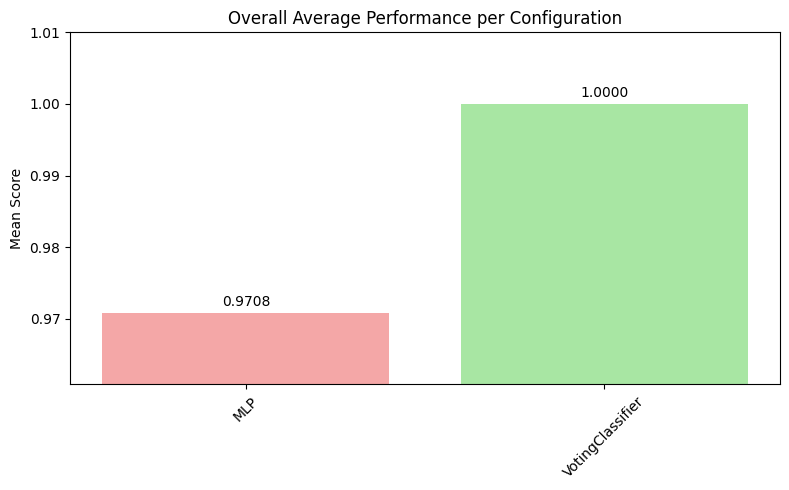

In [ ]:
df["mean_score"] = df[["accuracy","precision","recall","f1_score"]].mean(axis=1)

max_value = df["mean_score"].max()
min_value = df["mean_score"].min()

pastel_green = "#A8E6A3"
pastel_red = "#F4A7A7"
pastel_yellow = "#F9E79F"

colors = []

for value in df["mean_score"]:
    if value == max_value:
        colors.append(pastel_green)
    elif value == min_value:
        colors.append(pastel_red)
    else:
        colors.append(pastel_yellow)

plt.figure(figsize=(8,5))

bars = plt.bar(df["configuration"], df["mean_score"], color=colors)

plt.ylim(df["mean_score"].min() - 0.01,
         df["mean_score"].max() + 0.01)

plt.xticks(rotation=45)
plt.ylabel("Mean Score")
plt.title("Overall Average Performance per Configuration")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.001,
             f"{yval:.4f}",
             ha='center',
             fontsize=10)

plt.tight_layout()
plt.show()

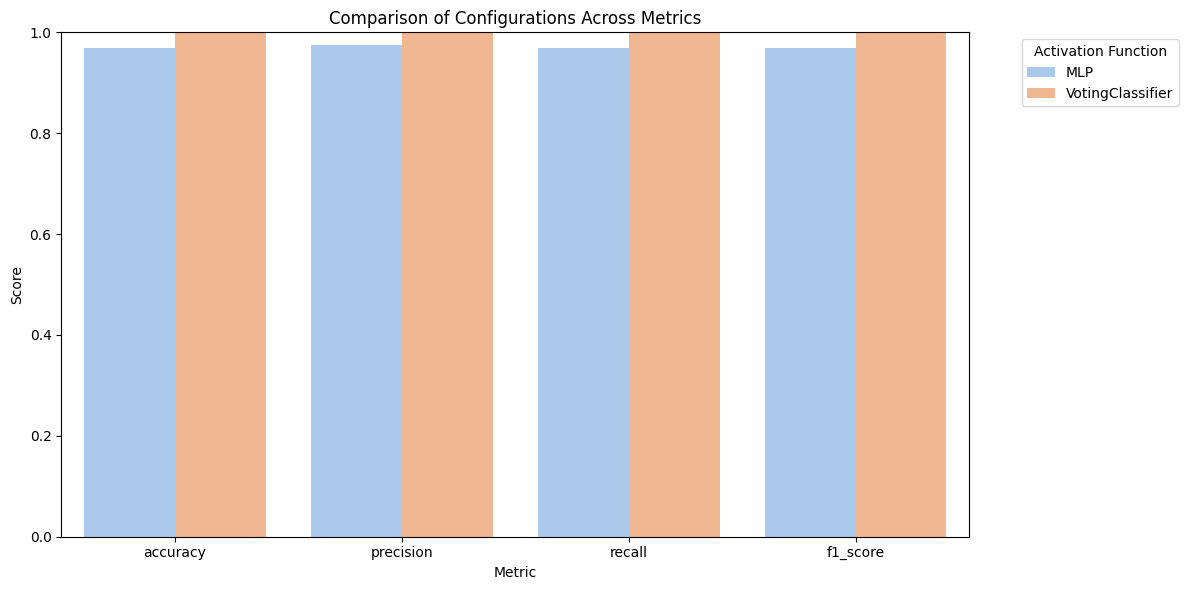

In [11]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="configuration",
    palette="pastel")


plt.title("Comparison of Configurations Across Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Activation Function", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

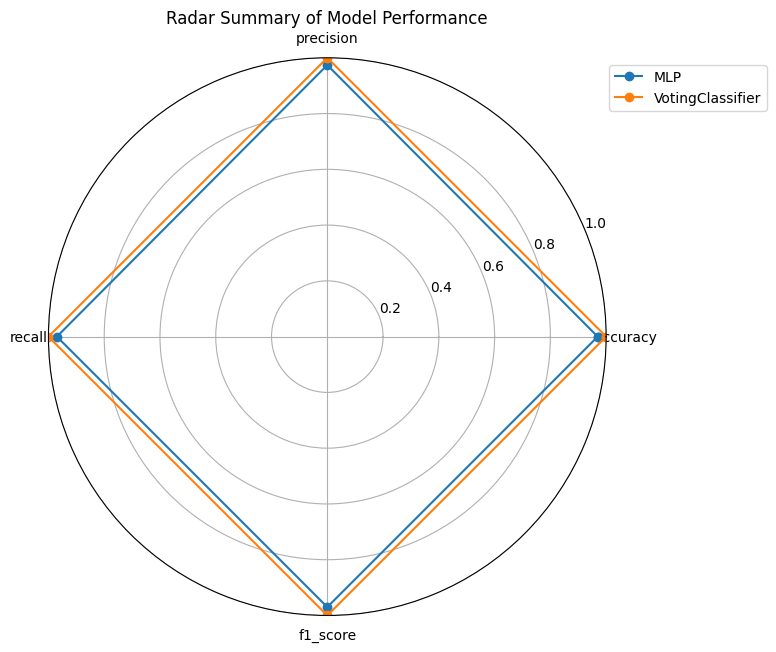

In [13]:
metrics = ["accuracy", "precision", "recall", "f1_score"]
labels = metrics
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))

for i in range(len(df)):
    values = df.loc[i, metrics].tolist()
    values += values[:1]
    
    plt.polar(angles, values, label=df.loc[i, "configuration"], marker='o')

plt.xticks(angles[:-1], labels)
plt.ylim(0, 1)
plt.title("Radar Summary of Model Performance")
plt.legend(bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

## **Conclusion**

The results show that the VotingClassifier combined with Xception features performs better than the MLP model across all evaluated metrics, including accuracy, precision, recall, and F1-score. This improvement can be attributed to the fact that the VotingClassifier is an ensemble model, which combines the predictions of multiple classifiers. By aggregating decisions from different models, ensemble methods often achieve higher stability and better generalization compared to a single model such as a Multilayer Perceptron (MLP).

Another important factor contributing to the strong performance is the use of transfer learning with the Xception convolutional neural network. Instead of training a deep CNN from scratch, the pretrained network is used as a feature extractor, leveraging knowledge learned from large datasets such as ImageNet. This approach allows the model to benefit from rich visual feature representations without requiring extensive training or massive datasets.

Finally, transfer learning significantly reduces computational cost and training time. Training deep convolutional networks from scratch typically requires large computational resources and long training periods. By freezing the pretrained layers and only training the final classifier, the system becomes much more efficient while still maintaining high predictive performance. This makes transfer learning combined with ensemble methods a practical and effective strategy for image classification tasks.